<a href="https://colab.research.google.com/github/maitrungtung/IMIS_Machine_Learning/blob/main/700/701_PyPorchPractice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 7. PyTorch Practice of Image Classification by Computer Vision

## Preface  

**Let's actually build a new image classifier.**  

Before you proceed beyond this point, think for a while how you will go if you are actually asked it?  


The original of this lesson is taken from ["Transfer learning tutorial"](https://pytorch.org/tutorials/beginner/transfer_learning_tutorial.html) given by PyTorch tutorial.  
As you see here, you can jump start by finding the right tutorial.

Since learning from scratch is time-consuming, we use a method called Transfer Learning to shorten the learning time.  

(Note that we are going to make a image classifier that can classify the images into the classes defined here.)


## (Difference between 700 and 800)

In the lesson 80x (mini-GPT) you built and trained a network **from scratch** and watched learning happen from first principles.  

Here we do the opposite move that real computer-vision systems rely on: we take a network **already trained** on millions of images (ImageNet) and **adapt** it to a new task with only a handful of examples. This is **transfer learning**, and it is why you can build a working classifier from a few dozen photos you take yourself.

You will train the same problem two ways and compare them:
- **`model_ft`** — *finetuning*: keep training every layer, starting from the pretrained weights.
- **`model_conv`** — *fixed feature extractor*: freeze the pretrained layers, train only the new final layer.


## Preparation as Google Colab

All the files will be placed on your Google Drive.

In [1]:
!echo "Start mounting your Google Drive."
from google.colab import drive
drive.mount('/content/drive')

Start mounting your Google Drive.
Mounted at /content/drive


In [2]:
!echo "Make a working folder and move to there."
%cd /content/drive/My\ Drive/
%mkdir -p IMIS_Tool-A/Work700
%cd       IMIS_Tool-A/Work700
!ls

Make a working folder and move to there.
/content/drive/My Drive
/content/drive/My Drive/IMIS_Tool-A/Work700
data


In [3]:
!echo "For tips on running notebooks in Google Colab, see https://pytorch.org/tutorials/beginner/colab "
%matplotlib inline

For tips on running notebooks in Google Colab, see https://pytorch.org/tutorials/beginner/colab 



# Transfer Learning for Computer Vision Tutorial
**Author**: [Sasank Chilamkurthy](https://chsasank.github.io)  
**Author(minor changes)**: KAMEDA Yoshinari

## Instroduction

In this tutorial, you will learn how to train a convolutional neural network for image classification using transfer learning.  
You can read more about the transfer learning at [cs231n notes](https://cs231n.github.io/transfer-learning/)_

Quoting these notes,

    In practice, very few people train an entire Convolutional Network
    from scratch (with random initialization), because it is relatively
    rare to have a dataset of sufficient size. Instead, it is common to
    pretrain a ConvNet on a very large dataset (e.g. ImageNet, which
    contains 1.2 million images with 1000 categories), and then use the
    ConvNet either as an initialization or a fixed feature extractor for
    the task of interest.

These two major transfer learning scenarios look as follows:

-  **Finetuning the ConvNet (model_ft)** : Instead of random initialization, we initialize the network with a pretrained network, like the one that is trained on imagenet 1000 dataset. Rest of the training looks as usual.
-  **ConvNet as fixed feature extractor (model_conv)**: Here, we will freeze the weights for all of the network except that of the final fully connected layer. This last fully connected layer is replaced with a new one with random weights and only this layer is trained.





## ImageNet

You should learn the imagenet and understand how big the size of the image dataset is to build a good classifier.

* ImageNet (official)  
   https://www.image-net.org/download.php  


## Preparation

Loading necessary libraries (as PyTorch).

In [4]:
# License: BSD
# Author: Sasank Chilamkurthy

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.backends.cudnn as cudnn
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
from PIL import Image
from tempfile import TemporaryDirectory

cudnn.benchmark = True

# reproducibility for the in-class demo
import random
torch.manual_seed(0); np.random.seed(0); random.seed(0)

In [5]:
# Create my own dataset folders
!rm -rf data/hymenoptera_data

!mkdir -p data/hymenoptera_data/train/bottle
!mkdir -p data/hymenoptera_data/train/calculator
!mkdir -p data/hymenoptera_data/val/bottle
!mkdir -p data/hymenoptera_data/val/calculator

!find data/hymenoptera_data -type d

data/hymenoptera_data
data/hymenoptera_data/train
data/hymenoptera_data/train/bottle
data/hymenoptera_data/train/calculator
data/hymenoptera_data/val
data/hymenoptera_data/val/bottle
data/hymenoptera_data/val/calculator


In [5]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Using CPU")

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


## Load Data (from the Internet)

We will use torchvision and torch.utils.data packages for loading the data.

The problem we're going to solve today is to train a model to classify **ants** and **bees**. We have about 120 training images each for ants and bees.
There are 75 validation images for each class. Usually, this is a very small dataset to generalize upon, if trained from scratch.
Since we are using transfer learning, we should be able to generalize reasonably well.

This dataset is a very small subset of imagenet.


In [ ]:
# Load the dataset and unzip it.
# (Plain ! commands are more robust on current Colab than the %%shell magic,
#  which is Colab-specific and raises on a non-zero exit code.)

!rm -rf data/
!wget -q -P ./data https://download.pytorch.org/tutorial/hymenoptera_data.zip
!unzip -q ./data/hymenoptera_data.zip -d ./data

Note that you do not need to run this process for the second time as the dataset is on your drive.  

You should check the data very well (this time one data file is actually corrupted).

In [6]:
import os

base = "/content/drive/My Drive/IMIS_Tool-A/Work700/data/hymenoptera_data"

print("Dataset exists:", os.path.exists(base))
print("Contents:", os.listdir(base))

Dataset exists: True
Contents: ['train', 'val']


In [7]:
from torchvision import datasets, transforms

data_dir = base

data_transforms = {
    "train": transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(
            [0.485, 0.456, 0.406],
            [0.229, 0.224, 0.225]
        )
    ]),

    "val": transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(
            [0.485, 0.456, 0.406],
            [0.229, 0.224, 0.225]
        )
    ])
}

image_datasets = {
    x: datasets.ImageFolder(
        os.path.join(data_dir, x),
        data_transforms[x]
    )
    for x in ["train", "val"]
}

print("Classes:", image_datasets["train"].classes)
print("Train:", len(image_datasets["train"]))
print("Validation:", len(image_datasets["val"]))

Classes: ['bottle', 'calculator']
Train: 30
Validation: 10


In [8]:
dataloaders = {
    x: torch.utils.data.DataLoader(
        image_datasets[x],
        batch_size=4,
        shuffle=True,
        num_workers=2
    )
    for x in ["train", "val"]
}

dataset_sizes = {
    x: len(image_datasets[x])
    for x in ["train", "val"]
}

class_names = image_datasets["train"].classes

device = torch.device(
    "cuda:0" if torch.cuda.is_available() else "cpu"
)

print("Dataset sizes:", dataset_sizes)
print("Class names:", class_names)
print("Device:", device)

Dataset sizes: {'train': 30, 'val': 10}
Class names: ['bottle', 'calculator']
Device: cuda:0


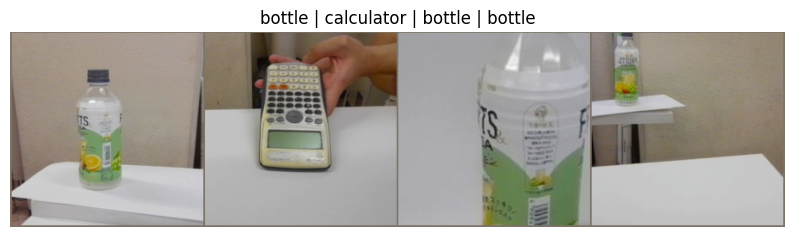

In [9]:
import matplotlib.pyplot as plt
import torchvision

# Get a batch of training images
inputs, classes = next(iter(dataloaders["train"]))

# Make a grid of images
out = torchvision.utils.make_grid(inputs)

# Convert from Tensor to numpy
out = out.numpy().transpose((1, 2, 0))

# Undo normalization
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

out = std * out + mean
out = out.clip(0, 1)

plt.figure(figsize=(10, 6))
plt.imshow(out)
plt.title(
    " | ".join([class_names[x] for x in classes])
)
plt.axis("off")
plt.show()

## Dataset tuning for use here

This process is sometimes critical for the classification performance.

* Augmentation and normalization for training
* Normalization for validation

(Why augmentation won't be applied to validation?)  
(What is the normalized image size?)  
(What happens if the image is larger or smaller? Not square?)  
(What will be done for the color balance?)  
(What is the magic number of [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]?)  
(What are the "augmentation"?)  

Check the actual commands to do these.

In [ ]:
!ls ./data/hymenoptera_data/train
!ls ./data/hymenoptera_data/val

In [ ]:
# Dataset definition for use

# Data augmentation and normalization for training
# Just normalization for validation

data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

data_dir = 'data/hymenoptera_data'
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x])
                  for x in ['train', 'val']}



## Data loader  

You should obtain the Google Colab runtime with GPU.  

(What is the batch_size?)  
(What is controlled by "shuffle=True"?)  
(What is num_workers?)  
(What is the role of "device"?)  
  
(What the warning is saying? ... See the lesson of 200)


In [ ]:
# Data loader for train and val

dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=4, shuffle=True, num_workers=2)
              for x in ['train', 'val']}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = image_datasets['train'].classes

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

## Check what you have done

You can see some variables by just typing the valiable name.

In [ ]:
# Uncomment one of these
#print("abc")
#data_transforms
#data_transforms['train']
#data_transforms['train'].transforms
#data_transforms['val']
#data_dir
#image_datasets
#image_datasets['train']
#image_datasets['train'].classes
#image_datasets['train'].imgs
#image_datasets['train'].transforms
#image_datasets['val']
#dataloaders
class_names
#dataset_sizes

In [ ]:
!ls -1 data/hymenoptera_data/train/ants | wc -l
!ls -1 data/hymenoptera_data/train/bees | wc -l
!ls -1 data/hymenoptera_data/val/ants | wc -l
!ls -1 data/hymenoptera_data/val/bees | wc -l

You should find something goes wrong here!  

(What is the "wrong" issue?)  
(Find the reason why it happens and discuss it will harm the future process or not)  

In [ ]:
# Uncomment one these to see the image lists
# Or you should check the google drive to check images

!ls -1 data/hymenoptera_data/train/ants
#!ls -1 data/hymenoptera_data/train/bees
#!ls -1 data/hymenoptera_data/val/ants
#!ls -1 data/hymenoptera_data/val/bees


## Visualize a few images

Let's visualize a few training images so as to understand the data augmentations.  

(Note that the iter/next command pair is quite unique to python, and thanks to this pair, you can see new images everytime you run the second code cell.)  


In [10]:
def imshow(inp, title=None):
    """Display image for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)


torch.Size([3, 228, 906])
tensor([0, 0, 1, 0])


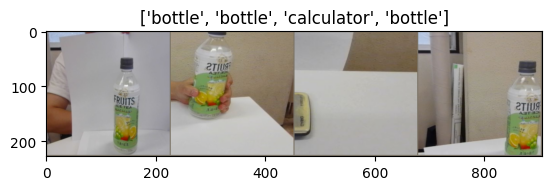

In [11]:
# Get a batch of training data

print(dataloaders['train'])
inputs, classes = next(iter(dataloaders['train']))

# Make a grid from batch
out = torchvision.utils.make_grid(inputs)
print(out.shape)

imshow(out, title=[class_names[x] for x in classes])

# 0...ants, 1...bees
print(classes)

In [12]:
# See the dimensions (shape) of images here.
# What do 4, 3, 224, and 224 mean?

inputs.shape

torch.Size([4, 3, 224, 224])

In [13]:
# See how the true labels are given

print(classes[0])
print(classes[1])
print(classes[2])
print(classes[3])

tensor(0)
tensor(0)
tensor(1)
tensor(0)


## Generic preparation

### On training the model

Now, let's write a **general** function to train a model. Here, we will illustrate:

-  Scheduling the learning rate
-  Saving the best model

In the following, parameter ``scheduler`` is an LR scheduler object from ``torch.optim.lr_scheduler``.



In [14]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=25):
    since = time.time()

    # Create a temporary directory to save training checkpoints
    with TemporaryDirectory() as tempdir:
        best_model_params_path = os.path.join(tempdir, 'best_model_params.pt')

        torch.save(model.state_dict(), best_model_params_path)
        best_acc = 0.0

        for epoch in range(num_epochs):
            print(f'Epoch {epoch}/{num_epochs - 1}')
            print('-' * 10)

            # Each epoch has a training and validation phase
            for phase in ['train', 'val']:
                if phase == 'train':
                    model.train()  # Set model to training mode
                else:
                    model.eval()   # Set model to evaluate mode

                running_loss = 0.0
                running_corrects = 0

                # Iterate over data.
                for inputs, labels in dataloaders[phase]:
                    inputs = inputs.to(device)
                    labels = labels.to(device)

                    # zero the parameter gradients
                    optimizer.zero_grad()

                    # forward
                    # track history if only in train
                    with torch.set_grad_enabled(phase == 'train'):
                        outputs = model(inputs)
                        _, preds = torch.max(outputs, 1)
                        loss = criterion(outputs, labels)

                        # backward + optimize only if in training phase
                        if phase == 'train':
                            loss.backward()
                            optimizer.step()

                    # statistics
                    running_loss += loss.item() * inputs.size(0)
                    running_corrects += torch.sum(preds == labels.data)
                if phase == 'train':
                    scheduler.step()

                epoch_loss = running_loss / dataset_sizes[phase]
                epoch_acc = running_corrects.double() / dataset_sizes[phase]

                print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

                # deep copy the model
                if phase == 'val' and epoch_acc > best_acc:
                    best_acc = epoch_acc
                    torch.save(model.state_dict(), best_model_params_path)

            print()

        time_elapsed = time.time() - since
        print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
        print(f'Best val Acc: {best_acc:4f}')

        # load best model weights
        model.load_state_dict(torch.load(best_model_params_path))
    return model

### On visualizing the model predictions

Generic function to display predictions for a few images.  
Note that the images are taken from "val" dataset.  




In [15]:
def visualize_model(model, num_images=6):
    was_training = model.training
    model.eval()
    images_so_far = 0
    fig = plt.figure()

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloaders['val']):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(num_images//2, 2, images_so_far)
                ax.axis('off')
                ax.set_title(f'predicted: {class_names[preds[j]]}')
                # 0 ant, 1 bee
                # print(preds[j])
                imshow(inputs.cpu().data[j])

                if images_so_far == num_images:
                    model.train(mode=was_training)
                    return
        model.train(mode=was_training)

---
## Main process (1): Finetuning the ConvNet (model_ft)

We plan to run fine-tuning here to let the default pretained model classify ants and bees.



### A pretrained model

Load a pretrained model (from strage space to memory) and reset the final fully connected layer.

In [16]:
# 'IMAGENET1K_V1' loads ImageNet-pretrained weights.
# (Equivalent modern form: weights=models.ResNet18_Weights.DEFAULT)
# Download a pretrained model that does not know ants/bees.
model_ft = models.resnet18(weights='IMAGENET1K_V1')
num_ftrs = model_ft.fc.in_features
# Here the size of each output sample is set to 2.
# Alternatively, it can be generalized to ``nn.Linear(num_ftrs, len(class_names))``.
model_ft.fc = nn.Linear(num_ftrs, 2)

model_ft = model_ft.to(device)

criterion = nn.CrossEntropyLoss()

# Observe that all parameters are being optimized
optimizer_ft = optim.SGD(model_ft.parameters(), lr=0.001, momentum=0.9)

# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 134MB/s]


### Before finetuning

Let's confirm that the downloaded pretrained model cannot classify ants and bees (as these two classes aew new to the model).  
How do you think about? Is it smart?  

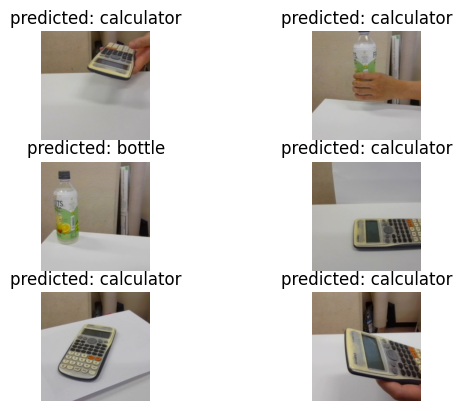

In [17]:
# Bad results?
visualize_model(model_ft)

### Train !! (finetuning)

It should take around 15-25 min on CPU.  
On GPU though, it takes less than a minute.

FYI: At a past test run;

* 23:43 on CPU (Intel(R) Xeon(R) CPU @ 2.20GHz x 2 processor)  
*  1:30 on GPU (Intel(R) Xeon(R) CPU @ 2.30GHz x 2 + Tesla-T4)


In [18]:
!cat /proc/cpuinfo

processor	: 0
vendor_id	: GenuineIntel
cpu family	: 6
model		: 85
model name	: Intel(R) Xeon(R) CPU @ 2.00GHz
stepping	: 3
microcode	: 0xffffffff
cpu MHz		: 2000.146
cache size	: 39424 KB
physical id	: 0
siblings	: 2
core id		: 0
cpu cores	: 1
apicid		: 0
initial apicid	: 0
fpu		: yes
fpu_exception	: yes
cpuid level	: 13
wp		: yes
flags		: fpu vme de pse tsc msr pae mce cx8 apic sep mtrr pge mca cmov pat pse36 clflush mmx fxsr sse sse2 ss ht syscall nx pdpe1gb rdtscp lm constant_tsc rep_good nopl xtopology nonstop_tsc cpuid tsc_known_freq pni pclmulqdq ssse3 fma cx16 pcid sse4_1 sse4_2 x2apic movbe popcnt aes xsave avx f16c rdrand hypervisor lahf_lm abm 3dnowprefetch ssbd ibrs ibpb stibp fsgsbase tsc_adjust bmi1 hle avx2 smep bmi2 erms invpcid rtm mpx avx512f avx512dq rdseed adx smap clflushopt clwb avx512cd avx512bw avx512vl xsaveopt xsavec xgetbv1 xsaves arat md_clear arch_capabilities
bugs		: cpu_meltdown spectre_v1 spectre_v2 spec_store_bypass l1tf mds swapgs taa mmio_stale_data re

In [19]:
# This will fails when you have a CPU-only runtime
!nvidia-smi

Sun Aug  9 09:14:41 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   47C    P0             29W /   70W |     229MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [20]:
# Warning: it takes time!

model_ft   = train_model(model_ft, criterion, optimizer_ft, exp_lr_scheduler, num_epochs=15)


Epoch 0/14
----------
train Loss: 0.6233 Acc: 0.6667
val Loss: 0.2573 Acc: 0.9000

Epoch 1/14
----------
train Loss: 0.4414 Acc: 0.8667
val Loss: 0.0447 Acc: 1.0000

Epoch 2/14
----------
train Loss: 0.5232 Acc: 0.7000
val Loss: 0.0535 Acc: 1.0000

Epoch 3/14
----------
train Loss: 0.2061 Acc: 0.9333
val Loss: 0.0159 Acc: 1.0000

Epoch 4/14
----------
train Loss: 0.3055 Acc: 0.8667
val Loss: 0.0108 Acc: 1.0000

Epoch 5/14
----------
train Loss: 0.9351 Acc: 0.7333
val Loss: 0.0121 Acc: 1.0000

Epoch 6/14
----------
train Loss: 0.3845 Acc: 0.8333
val Loss: 0.1337 Acc: 1.0000

Epoch 7/14
----------
train Loss: 0.4421 Acc: 0.7667
val Loss: 0.0646 Acc: 1.0000

Epoch 8/14
----------
train Loss: 0.2890 Acc: 0.9000
val Loss: 0.0265 Acc: 1.0000

Epoch 9/14
----------
train Loss: 0.4797 Acc: 0.7333
val Loss: 0.0095 Acc: 1.0000

Epoch 10/14
----------
train Loss: 0.5953 Acc: 0.6667
val Loss: 0.0036 Acc: 1.0000

Epoch 11/14
----------
train Loss: 0.0723 Acc: 1.0000
val Loss: 0.0026 Acc: 1.0000

Ep

### Check the result on "val" dataset

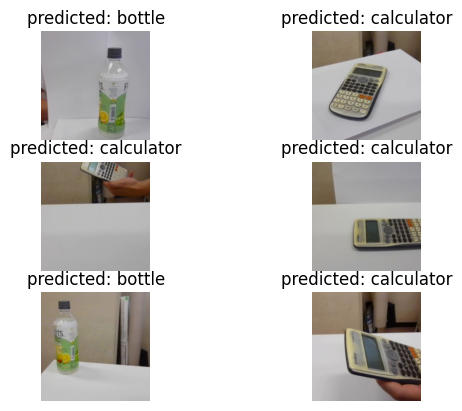

In [21]:
# Good results?
visualize_model(model_ft)

---
## Main process (2): ConvNet as fixed feature extractor (model_conv)

We take transfer-learning approach to let the pretrained model smart.  

### learning at the final layer only

Here, we need to freeze all the network except the final layer.   
We need to set ``requires_grad = False`` to freeze the parameters so that the gradients are not computed in ``backward()``.

You can read more about this in the documentation [here](https://pytorch.org/docs/notes/autograd.html#excluding-subgraphs-from-backward)_.


In [22]:
# Download a pretrained model that does not know ants/bees.
model_conv = torchvision.models.resnet18(weights='IMAGENET1K_V1')
for param in model_conv.parameters():
    param.requires_grad = False

# Parameters of newly constructed modules have requires_grad=True by default
num_ftrs = model_conv.fc.in_features
model_conv.fc = nn.Linear(num_ftrs, 2)

model_conv = model_conv.to(device)

criterion = nn.CrossEntropyLoss()

# Observe that only parameters of final layer are being optimized as
# opposed to before.
optimizer_conv = optim.SGD(model_conv.fc.parameters(), lr=0.001, momentum=0.9)

# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_conv, step_size=7, gamma=0.1)

### Before transfer-learning

Let's confirm that the downloaded pretrained model cannot classify ants and bees (as these two classes aew new to the model).  
How do you think about? Is it smart?  

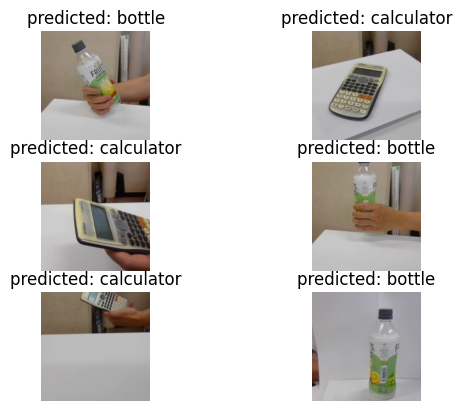

In [23]:
# Bad results?
visualize_model(model_ft)

### Train !! (transfer-leaninng)

On CPU this will take about half the time compared to previous scenario.
This is expected as gradients don't need to be computed for most of the network. However, forward does need to be computed.

FYI: At the test run;

* 10:55 on CPU (Intel(R) Xeon(R) CPU @ 2.20GHz x 2 processor)  
*  1:34 on GPU (Intel(R) Xeon(R) CPU @ 2.30GHz x 2 + Tesla-T4)

(Unfortunately, the time-shortning won't be so successful on GPU-runtime probably because of the small traning size.)


In [24]:
!cat /proc/cpuinfo

processor	: 0
vendor_id	: GenuineIntel
cpu family	: 6
model		: 85
model name	: Intel(R) Xeon(R) CPU @ 2.00GHz
stepping	: 3
microcode	: 0xffffffff
cpu MHz		: 2000.146
cache size	: 39424 KB
physical id	: 0
siblings	: 2
core id		: 0
cpu cores	: 1
apicid		: 0
initial apicid	: 0
fpu		: yes
fpu_exception	: yes
cpuid level	: 13
wp		: yes
flags		: fpu vme de pse tsc msr pae mce cx8 apic sep mtrr pge mca cmov pat pse36 clflush mmx fxsr sse sse2 ss ht syscall nx pdpe1gb rdtscp lm constant_tsc rep_good nopl xtopology nonstop_tsc cpuid tsc_known_freq pni pclmulqdq ssse3 fma cx16 pcid sse4_1 sse4_2 x2apic movbe popcnt aes xsave avx f16c rdrand hypervisor lahf_lm abm 3dnowprefetch ssbd ibrs ibpb stibp fsgsbase tsc_adjust bmi1 hle avx2 smep bmi2 erms invpcid rtm mpx avx512f avx512dq rdseed adx smap clflushopt clwb avx512cd avx512bw avx512vl xsaveopt xsavec xgetbv1 xsaves arat md_clear arch_capabilities
bugs		: cpu_meltdown spectre_v1 spectre_v2 spec_store_bypass l1tf mds swapgs taa mmio_stale_data re

In [25]:
# This will fails when you have a CPU-only runtime
!nvidia-smi

Sun Aug  9 09:15:38 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   54C    P0             30W /   70W |     413MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [26]:
# Warning: it takes time!

model_conv = train_model(model_conv, criterion, optimizer_conv, exp_lr_scheduler, num_epochs=15)

Epoch 0/14
----------
train Loss: 0.9246 Acc: 0.3333
val Loss: 0.4850 Acc: 0.8000

Epoch 1/14
----------
train Loss: 0.5771 Acc: 0.5333
val Loss: 0.1749 Acc: 1.0000

Epoch 2/14
----------
train Loss: 0.4206 Acc: 0.8333
val Loss: 0.0831 Acc: 1.0000

Epoch 3/14
----------
train Loss: 0.3563 Acc: 0.8000
val Loss: 0.0542 Acc: 1.0000

Epoch 4/14
----------
train Loss: 0.4953 Acc: 0.8000
val Loss: 0.0417 Acc: 1.0000

Epoch 5/14
----------
train Loss: 0.2446 Acc: 0.9333
val Loss: 0.0334 Acc: 1.0000

Epoch 6/14
----------
train Loss: 0.5139 Acc: 0.8000
val Loss: 0.0501 Acc: 1.0000

Epoch 7/14
----------
train Loss: 0.2968 Acc: 0.8667
val Loss: 0.0514 Acc: 1.0000

Epoch 8/14
----------
train Loss: 0.1504 Acc: 0.9667
val Loss: 0.0410 Acc: 1.0000

Epoch 9/14
----------
train Loss: 0.2735 Acc: 0.8667
val Loss: 0.0322 Acc: 1.0000

Epoch 10/14
----------
train Loss: 0.1545 Acc: 0.9333
val Loss: 0.0296 Acc: 1.0000

Epoch 11/14
----------
train Loss: 0.2508 Acc: 0.8333
val Loss: 0.0250 Acc: 1.0000

Ep

### Check the results on "val" dataset

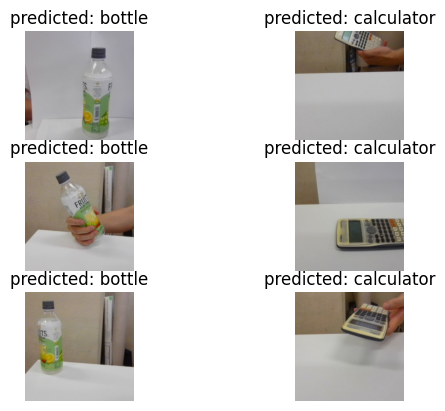

In [27]:
# Good results?
visualize_model(model_conv)


## Test on your own images

Use the newly trained model to make predictions on your own images and visualize
the predicted class labels along with the images.  
(Note that this could be done for both the finetuning process and the trasnfer-learning process.)




In [32]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode

def take_photo(filename='photo.jpg', quality=0.8):
    js = Javascript('''
        async function takePhoto(quality) {
            const div = document.createElement('div');

            const capture = document.createElement('button');
            capture.textContent = 'Capture';
            div.appendChild(capture);

            const video = document.createElement('video');
            video.style.display = 'block';

            const stream = await navigator.mediaDevices.getUserMedia({video: true});

            document.body.appendChild(div);
            div.appendChild(video);

            video.srcObject = stream;
            await video.play();

            google.colab.output.setIframeHeight(
                document.documentElement.scrollHeight,
                true
            );

            await new Promise((resolve) => capture.onclick = resolve);

            const canvas = document.createElement('canvas');
            canvas.width = video.videoWidth;
            canvas.height = video.videoHeight;

            canvas.getContext('2d').drawImage(video, 0, 0);

            stream.getVideoTracks()[0].stop();
            div.remove();

            return canvas.toDataURL('image/jpeg', quality);
        }
    ''')

    display(js)
    data = eval_js('takePhoto({})'.format(quality))
    binary = b64decode(data.split(',')[1])

    with open(filename, 'wb') as f:
        f.write(binary)

    return filename


===== Image 1/4 =====


<IPython.core.display.Javascript object>

Predicted class = bottle
Confidence = 90.84%

===== Image 2/4 =====


<IPython.core.display.Javascript object>

Predicted class = bottle
Confidence = 58.08%

===== Image 3/4 =====


<IPython.core.display.Javascript object>

Predicted class = calculator
Confidence = 90.47%

===== Image 4/4 =====


<IPython.core.display.Javascript object>

Predicted class = calculator
Confidence = 67.68%


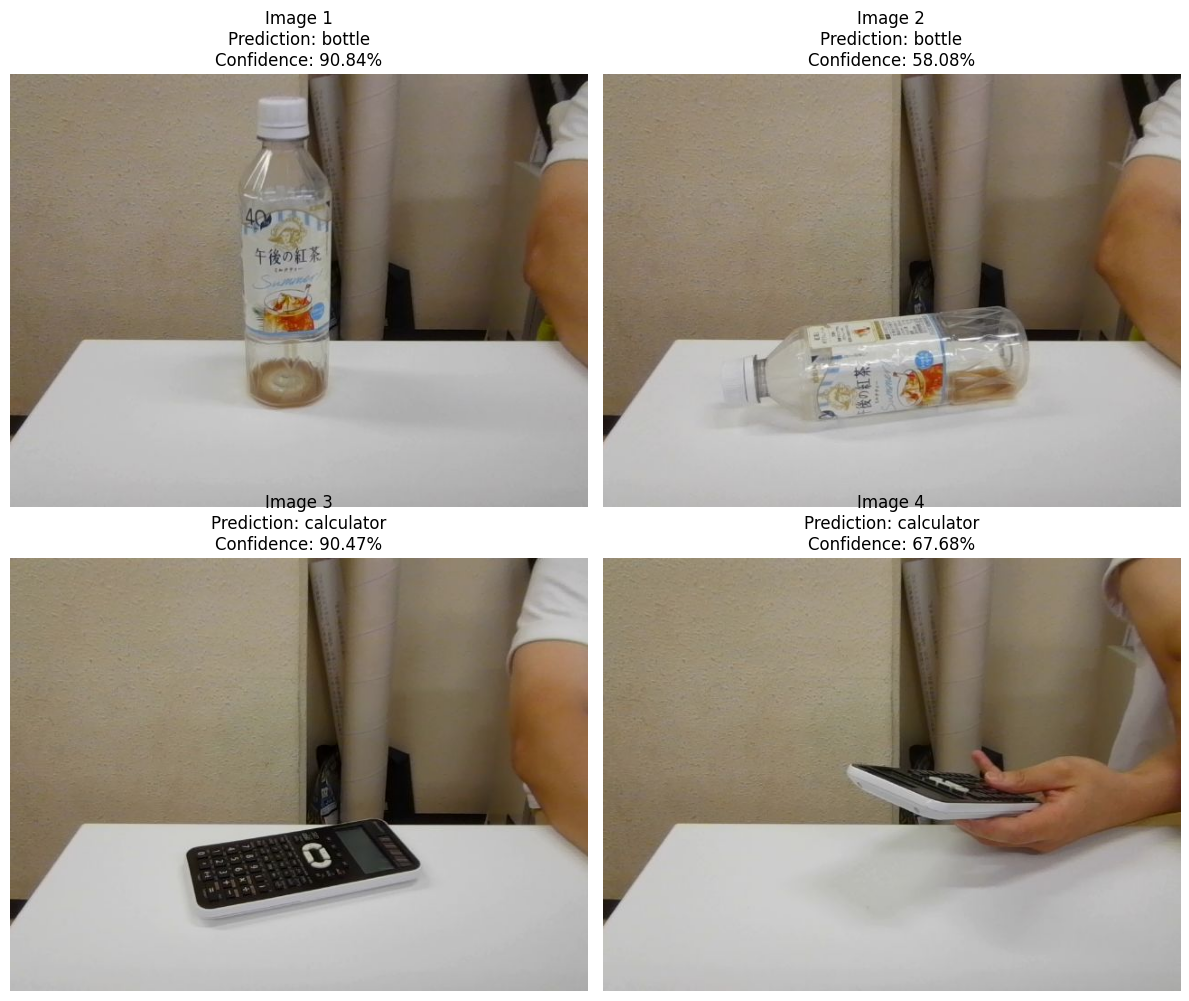

In [35]:
from PIL import Image
import matplotlib.pyplot as plt

# Number of images to capture
num_images = 4

results = []

for i in range(num_images):

    print(f"\n===== Image {i+1}/{num_images} =====")

    # Capture image
    filename = take_photo()

    # Load image
    image = Image.open(filename).convert("RGB")

    # Use the same preprocessing as validation
    input_tensor = data_transforms["val"](image)
    input_tensor = input_tensor.unsqueeze(0).to(device)

    # Prediction
    model_ft.eval()

    with torch.no_grad():
        output = model_ft(input_tensor)
        probabilities = torch.softmax(output, dim=1)

        confidence, predicted = torch.max(probabilities, 1)

    predicted_class = class_names[predicted.item()]
    confidence_value = confidence.item() * 100

    results.append({
        "image": image,
        "class": predicted_class,
        "confidence": confidence_value
    })

    print(f"Predicted class = {predicted_class}")
    print(f"Confidence = {confidence_value:.2f}%")

# Display all 4 results
plt.figure(figsize=(12, 10))

for i, result in enumerate(results):

    plt.subplot(2, 2, i + 1)

    plt.imshow(result["image"])

    plt.title(
        f"Image {i+1}\n"
        f"Prediction: {result['class']}\n"
        f"Confidence: {result['confidence']:.2f}%"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [28]:
def visualize_model_predictions(model,img_path):
    was_training = model.training
    model.eval()

    img = Image.open(img_path)
    img = data_transforms['val'](img)
    img = img.unsqueeze(0)
    img = img.to(device)

    with torch.no_grad():
        outputs = model(img)
        _, preds = torch.max(outputs, 1)

        ax = plt.subplot(2,2,1)
        ax.axis('on')
        ax.set_title(f'Predicted: {class_names[preds[0]], preds[0]}')
        imshow(img.cpu().data[0])

        model.train(mode=was_training)

Let's see the result of your own images.

In [29]:
# For example, find one on wikimedia (filename European_honey_bee_extracts_nectar.jpg)
# https://commons.wikimedia.org/
# Or bring some images from the Internet, or just capture an image on your camera

!wget https://upload.wikimedia.org/wikipedia/commons/1/1d/European_honey_bee_extracts_nectar.jpg

--2026-08-09 09:16:23--  https://upload.wikimedia.org/wikipedia/commons/1/1d/European_honey_bee_extracts_nectar.jpg
Resolving upload.wikimedia.org (upload.wikimedia.org)... 103.102.166.240, 2001:df2:e500:ed1a::2:b
Connecting to upload.wikimedia.org (upload.wikimedia.org)|103.102.166.240|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 501352 (490K) [image/jpeg]
Saving to: ‘European_honey_bee_extracts_nectar.jpg’

European_honey_bee_ 100%[===================>] 489.60K  --.-KB/s    in 0.02s   

2026-08-09 09:16:23 (29.8 MB/s) - ‘European_honey_bee_extracts_nectar.jpg’ saved [501352/501352]



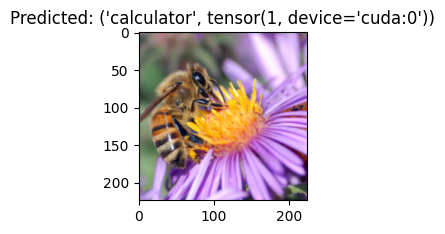

In [30]:
# Ask the class of your image !
img_path="European_honey_bee_extracts_nectar.jpg"

# by fine tuning model
visualize_model_predictions(
    model_ft,
    img_path
)

# by conv net model
visualize_model_predictions(
    model_conv,
    img_path
)

plt.show()

Do you think your trained model is (artificially) intelligent enough? 😋

---
---


# Building your own classifier with your image dataset

Let's build your won classifier.  

The strategy is simple. Just keep the original structure of this lesson.

* Two classes (By replacing ants and bees)
* Images from a USB camera!

## Folders to cook

In [ ]:
# Replace the ants/bees folders with your own two classes.
# IMPORTANT: do it for BOTH train/ and val/ so ImageFolder sees the same classes.
# Example (uncomment and edit the names):
# !rm -rf ./data/hymenoptera_data/train/ants ./data/hymenoptera_data/val/ants
# !rm -rf ./data/hymenoptera_data/train/bees ./data/hymenoptera_data/val/bees
# !mkdir -p ./data/hymenoptera_data/train/class1 ./data/hymenoptera_data/val/class1
# !mkdir -p ./data/hymenoptera_data/train/class2 ./data/hymenoptera_data/val/class2

## Tips to get images from camera capture

Taken from the help -> code snipet of google colab.

In [6]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode

def take_photo(filename='photo.jpg', quality=0.8):
  js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      const capture = document.createElement('button');
      capture.textContent = 'Capture';
      div.appendChild(capture);

      const video = document.createElement('video');
      video.style.display = 'block';
      const stream = await navigator.mediaDevices.getUserMedia({video: true});

      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();

      // Resize the output to fit the video element.
      google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

      // Wait for Capture to be clicked.
      await new Promise((resolve) => capture.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);
      stream.getVideoTracks()[0].stop();
      div.remove();
      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')
  display(js)
  data = eval_js('takePhoto({})'.format(quality))
  binary = b64decode(data.split(',')[1])
  with open(filename, 'wb') as f:
    f.write(binary)
  return filename
# NOTE: use a distinct name so we don't clash with PIL.Image imported earlier.
from IPython.display import Image as DisplayImage

In [7]:
# Configure your capture: which class folder, and how many shots now.
label   = 'class1'       # <- one of your class names (folder under train/)
n_shots = 20              # <- number of images to capture in this run
split   = 'train'        # <- 'train' or 'val'

<IPython.core.display.Javascript object>

Saved data/hymenoptera_data/train/class1/class1_001.jpg


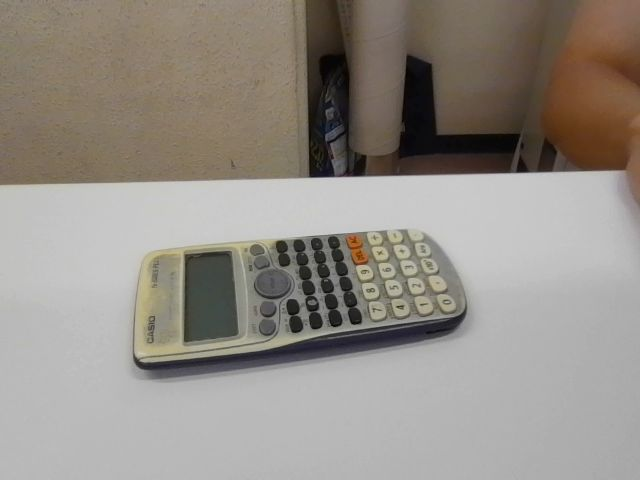

<IPython.core.display.Javascript object>

Saved data/hymenoptera_data/train/class1/class1_002.jpg


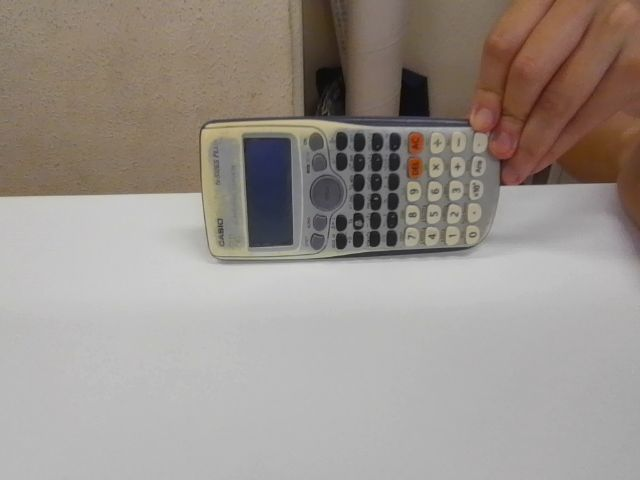

<IPython.core.display.Javascript object>

Saved data/hymenoptera_data/train/class1/class1_003.jpg


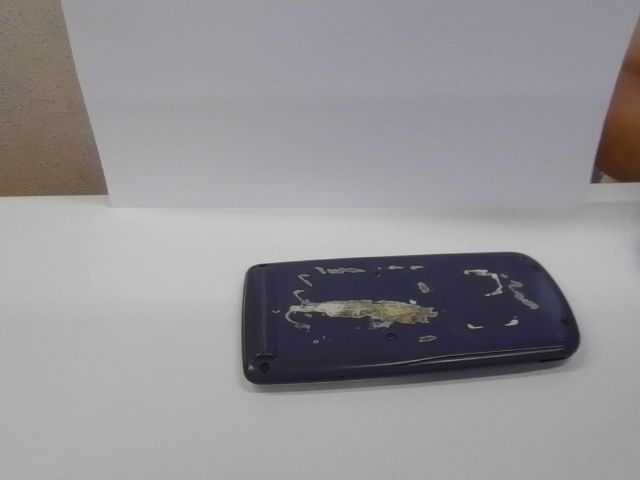

<IPython.core.display.Javascript object>

Saved data/hymenoptera_data/train/class1/class1_004.jpg


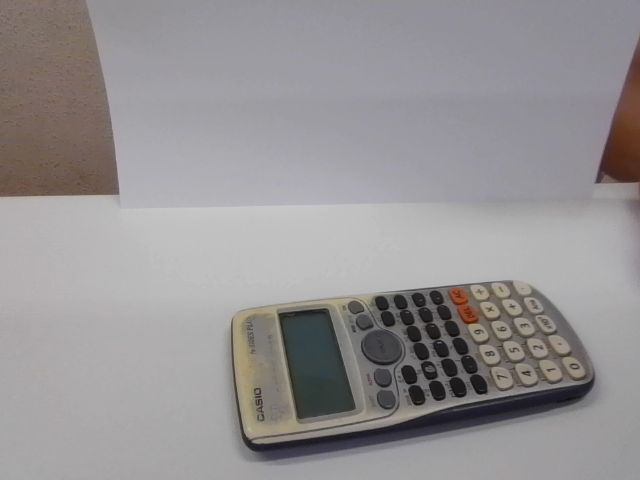

<IPython.core.display.Javascript object>

Saved data/hymenoptera_data/train/class1/class1_005.jpg


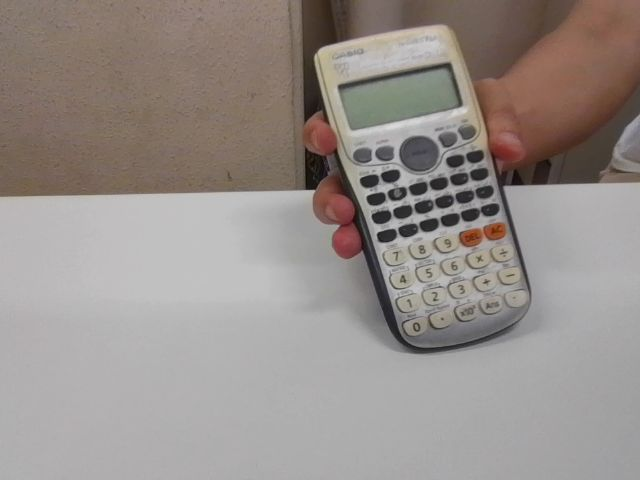

<IPython.core.display.Javascript object>

Saved data/hymenoptera_data/train/class1/class1_006.jpg


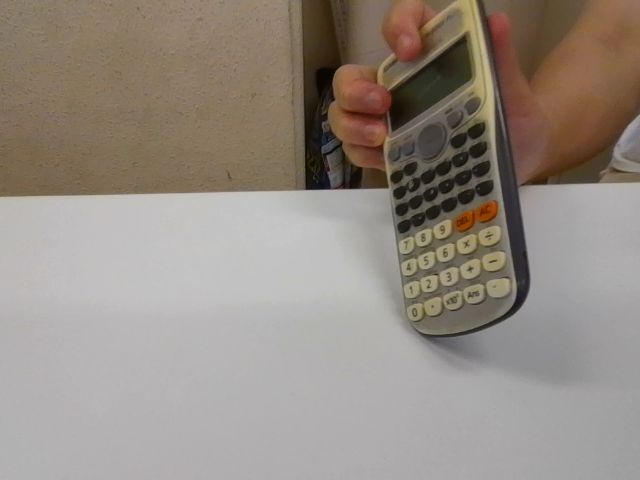

<IPython.core.display.Javascript object>

Saved data/hymenoptera_data/train/class1/class1_007.jpg


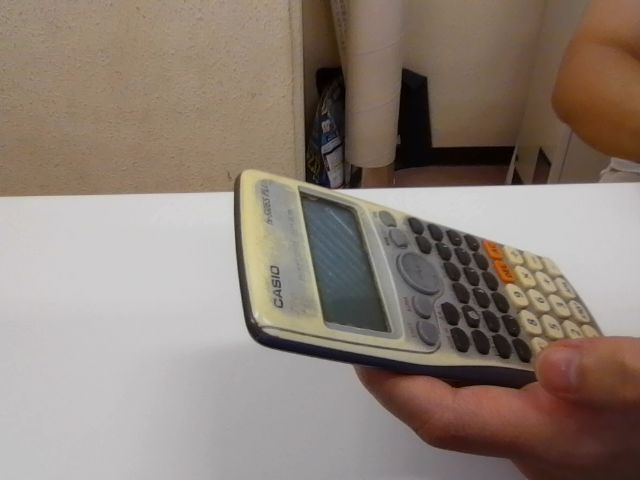

<IPython.core.display.Javascript object>

Saved data/hymenoptera_data/train/class1/class1_008.jpg


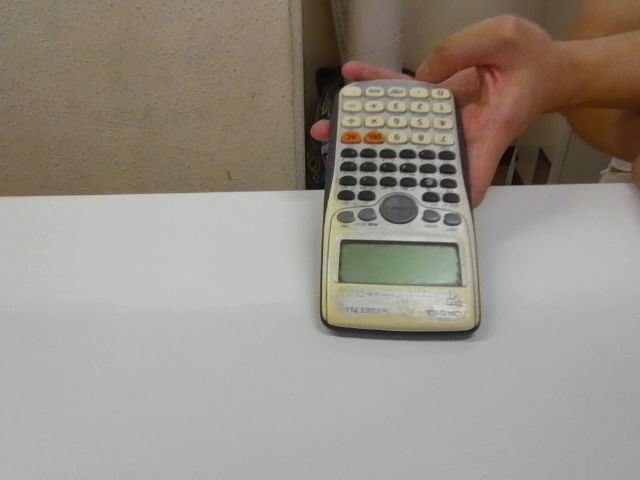

<IPython.core.display.Javascript object>

Saved data/hymenoptera_data/train/class1/class1_009.jpg


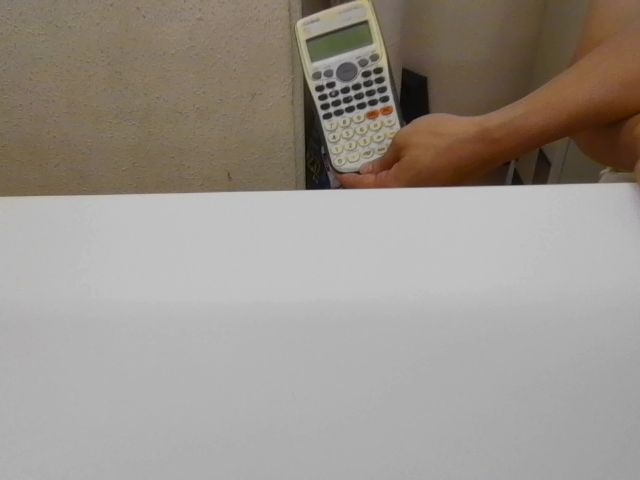

<IPython.core.display.Javascript object>

Saved data/hymenoptera_data/train/class1/class1_010.jpg


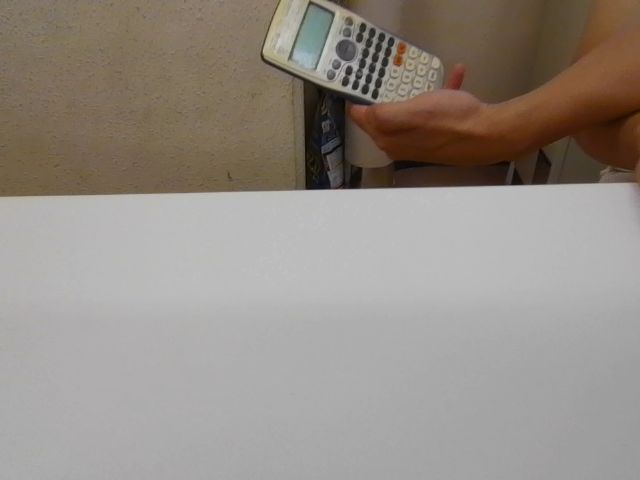

<IPython.core.display.Javascript object>

Saved data/hymenoptera_data/train/class1/class1_011.jpg


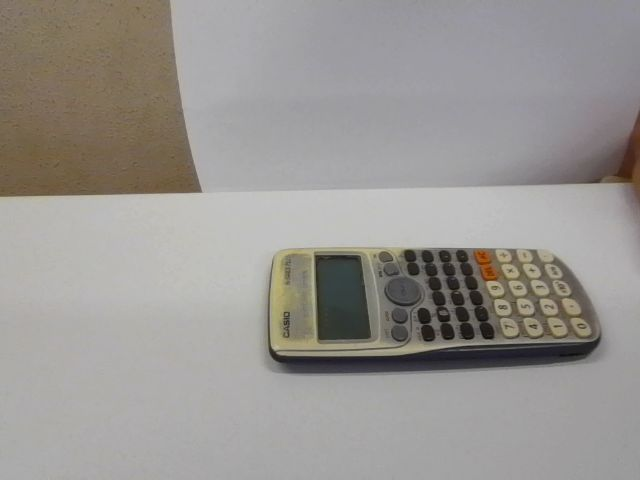

<IPython.core.display.Javascript object>

Saved data/hymenoptera_data/train/class1/class1_012.jpg


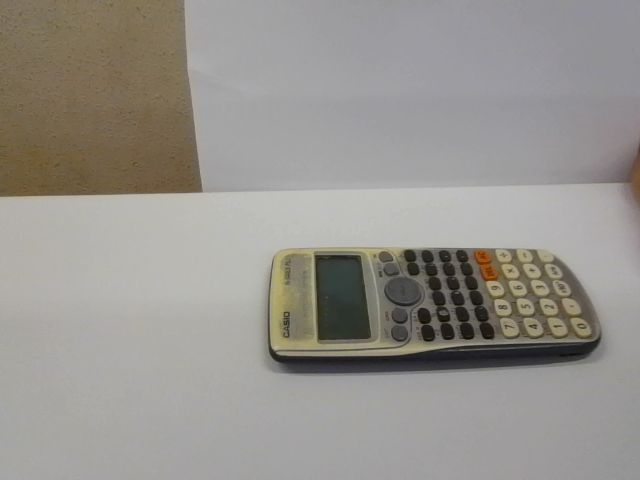

<IPython.core.display.Javascript object>

Saved data/hymenoptera_data/train/class1/class1_013.jpg


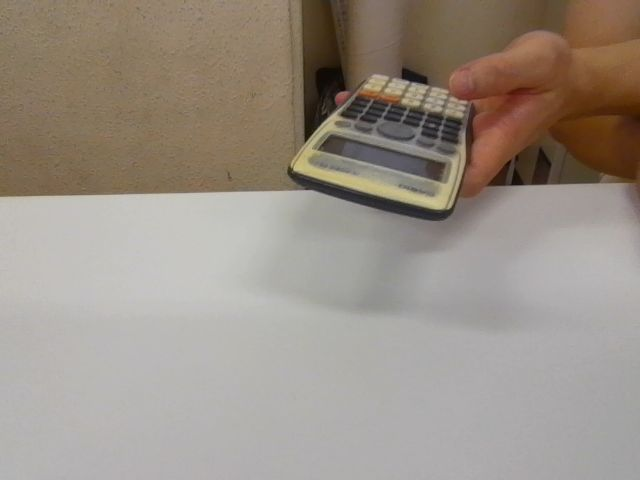

<IPython.core.display.Javascript object>

Saved data/hymenoptera_data/train/class1/class1_014.jpg


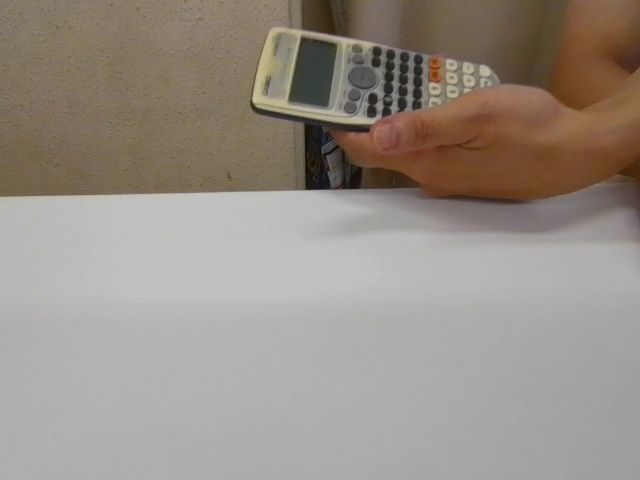

<IPython.core.display.Javascript object>

Saved data/hymenoptera_data/train/class1/class1_015.jpg


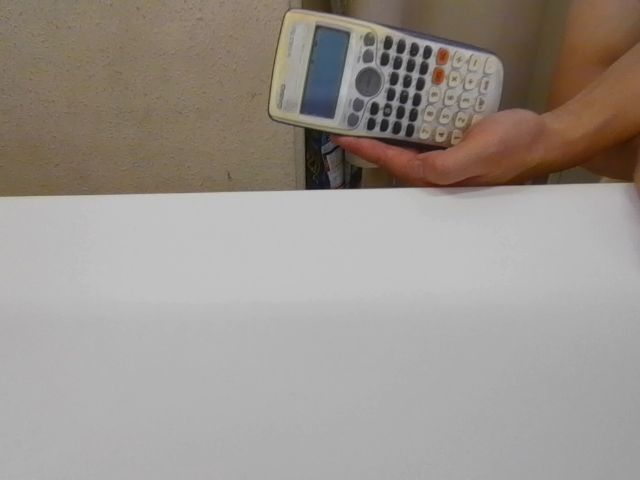

<IPython.core.display.Javascript object>

Saved data/hymenoptera_data/train/class1/class1_016.jpg


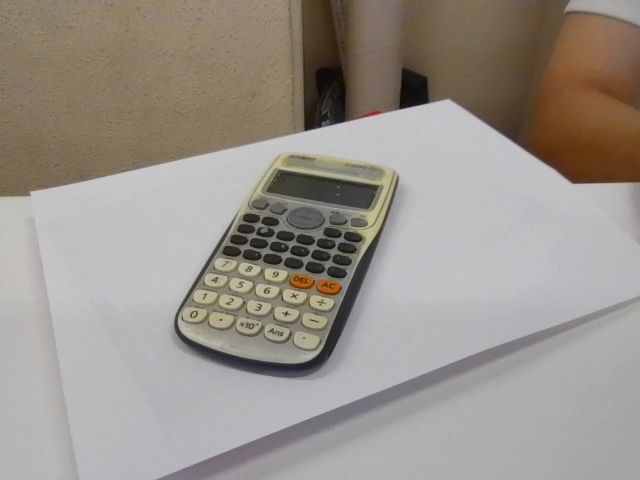

<IPython.core.display.Javascript object>

Saved data/hymenoptera_data/train/class1/class1_017.jpg


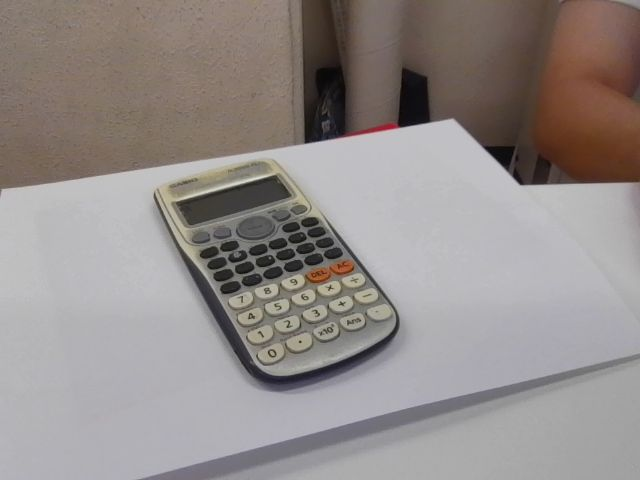

<IPython.core.display.Javascript object>

Saved data/hymenoptera_data/train/class1/class1_018.jpg


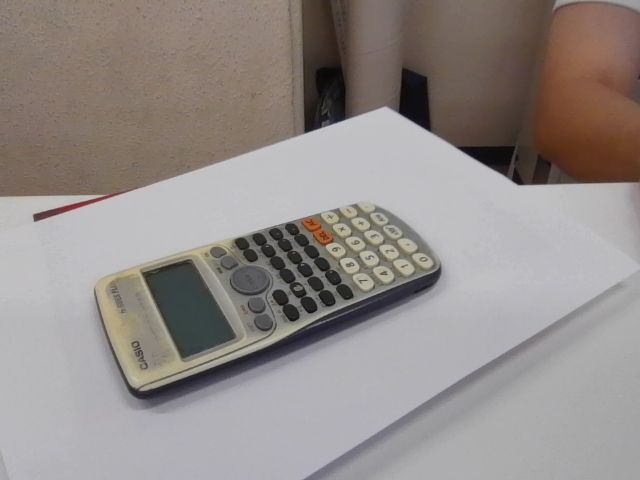

<IPython.core.display.Javascript object>

Saved data/hymenoptera_data/train/class1/class1_019.jpg


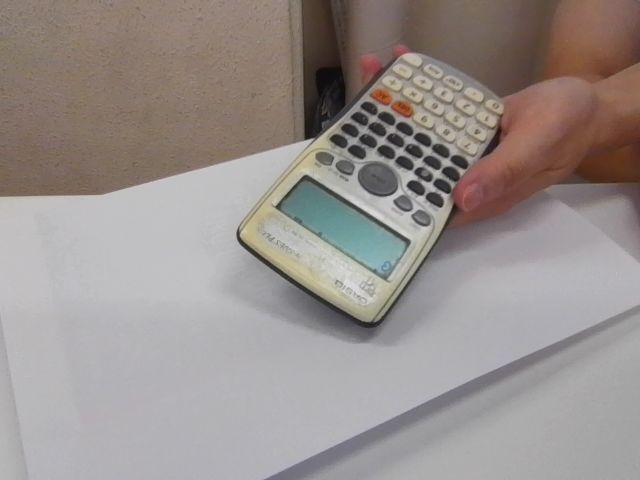

<IPython.core.display.Javascript object>

Saved data/hymenoptera_data/train/class1/class1_020.jpg


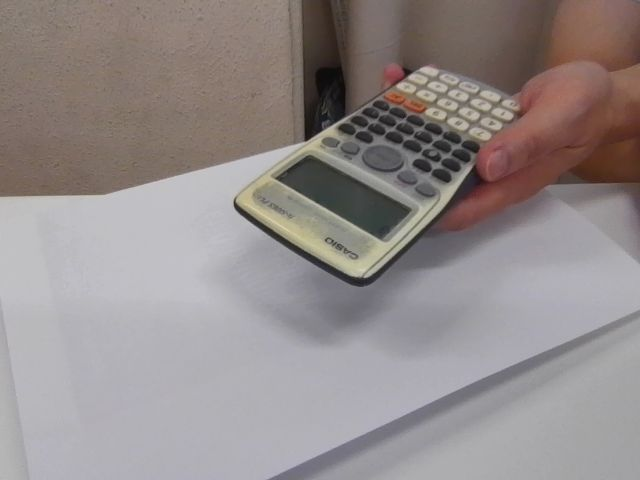

In [12]:
save_dir = f'data/hymenoptera_data/{split}/{label}'
os.makedirs(save_dir, exist_ok=True)
existing = len([f for f in os.listdir(save_dir) if f.lower().endswith('.jpg')])

for k in range(n_shots):
    idx = existing + k + 1
    try:
        path = take_photo(f'{save_dir}/{label}_{idx:03d}.jpg')
        print('Saved', path)
        display(DisplayImage(path))   # DisplayImage, NOT PIL.Image
    except Exception as err:
        # thrown if there is no webcam or permission was denied
        print('Camera error:', err)
        break

In [15]:
import os

base = "data/hymenoptera_data"

for split in ["train", "val"]:
    for cls in ["bottle", "calculator"]:
        folder = os.path.join(base, split, cls)
        n = len([f for f in os.listdir(folder)
                 if f.lower().endswith((".jpg",".jpeg",".png"))])
        print(f"{split}/{cls}: {n} images")

train/bottle: 15 images
train/calculator: 15 images
val/bottle: 5 images
val/calculator: 5 images


## Further study

* More than two classes
* Realtime USB camera image classification on the fly
* Investigation of the factors that make influence on classification performance
* Code cleaning (as this course's code is a mix of snipets ...)
* Implementation of the answer "none of the two"

---
Tools and Practices for Intelligent Interaction Systems A  
Master's and Docotal programs in intelligent and mechanical interaction systems, University of Tsukuba, Japan.  
KAMEDA Yoshinari, SHIBUYA Takeshi  

知能システムツール演習a  
知能機能システム学位プログラム (筑波大学大学院)  
担当：亀田能成，澁谷長史  

2026/08/03. (ver.701)  
2023/08/07. (ver.700)   
